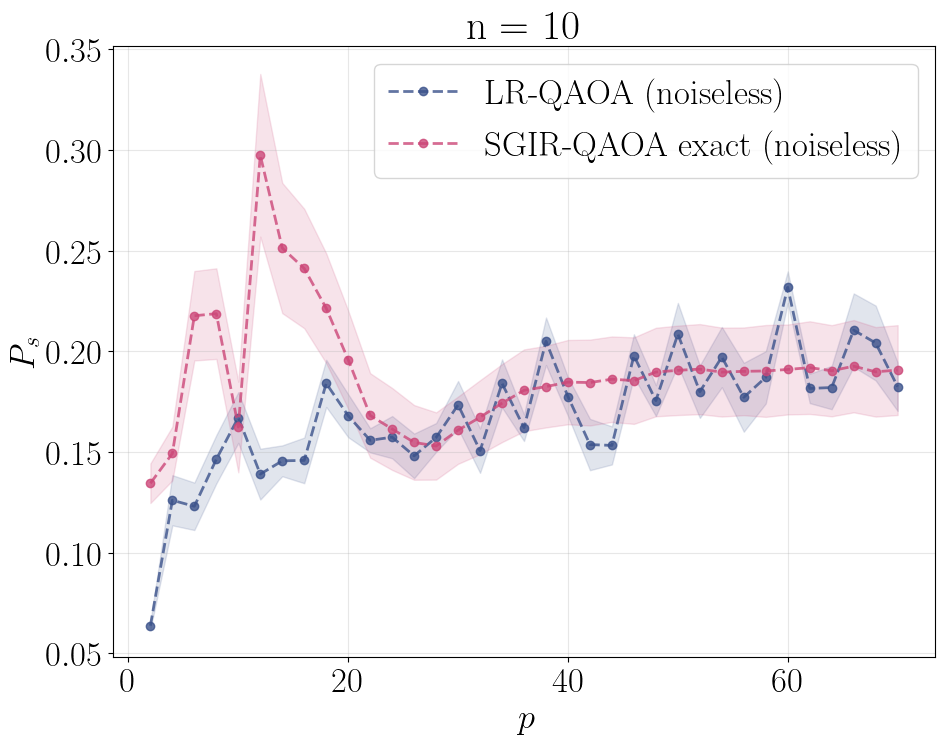

: 

In [ ]:
# -*- coding: utf-8 -*-
"""

Plot MIS Results

"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os

# =========================
# Parameters
# =========================

p_max = 70

pen = 100

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 25})

instance = 'n10'
pnoise = 0.001
# =========================
# CSV files
# =========================
csv_LR = ""#f"results/n10_noisy_pnoise0.001_no_renorm_pen100_LR-QAOA_2026_b[-1.5, 0.5]_g[-1, 1]_d20.csv"
csv_SG = ""#f"results/n10_noisy_pnoise0.001_no_renorm_pen100_SGIR-QAOA-0k_matrix_free_extrap_s0_gap4all_s1_gap0_2026_b[-1.5, 0.5]_g[-1, 1]_d20.csv"
csv_rand = f"results/big_random_b[-1.5, 0.5]_g[-1, 1]_d11_vRand.csv"
csv_SG_inv = f""

csv_LR_noiseless = f"results/n10_statevector_no_renorm_pen100_LR-QAOA_2026_b[-1.5, 0.5]_g[-1, 1]_d20.csv"
csv_SG_noiseless = f"results/n10_statevector_no_renorm_pen100_SGIR-QAOA-0k_matrix_free_extrap_s0_gap4all_s1_gap0_2026_b[-1.5, 0.5]_g[-1, 1]_d20.csv"

# =========================
# Load CSVs safely
# =========================

def load_csv_if_exists(path):
    if path and os.path.exists(path):
        return pd.read_csv(path, on_bad_lines='skip')
    return None

df_LR     = load_csv_if_exists(csv_LR)
df_SG     = load_csv_if_exists(csv_SG)
df_rand   = load_csv_if_exists(csv_rand)
df_SG_inv = load_csv_if_exists(csv_SG_inv)

df_LR_noiseless = load_csv_if_exists(csv_LR_noiseless)
df_SG_noiseless = load_csv_if_exists(csv_SG_noiseless)

# =========================
# Filter instances
# =========================

def filter_df(df,p_max):
    if df is not None:
        # Keep only the d3 instances
        df = df[df["instance"].str.contains(r"_d3_", na=False)]
        # Cut off at p = 16
        df = df[df["p"] <= p_max]
        return df
    return df

df_LR = filter_df(df_LR,p_max)
df_SG = filter_df(df_SG,p_max)
df_LR_noiseless = filter_df(df_LR_noiseless,p_max)
df_SG_noiseless = filter_df(df_SG_noiseless,p_max)

# =========================
# Methods
# =========================

methods = [
    ("LR-QAOA (noisy)", df_LR, cm.viridis(0.25), "-", 1.0),
    ("SGIR-QAOA exact (noisy)", df_SG, cm.plasma(0.5), "-", 1.0),
    ("Random params", df_rand, "black", "-", 1.0),
    ("LR-QAOA-CD-peakGap", df_SG_inv, "red", "-", 1.0),

    # noiseless (dashed)
    ("LR-QAOA (noiseless)", df_LR_noiseless, cm.viridis(0.25), "--", 0.8),
    ("SGIR-QAOA exact (noiseless)", df_SG_noiseless, cm.plasma(0.5), "--", 0.8),
]






# =========================
# Plot
# =========================

plt.figure(figsize=(10,8))

for name, df_method, color, linestyle, alpha in methods:

    if df_method is None or df_method.empty:
        continue

    # -------------------------
    # Average over instances
    # -------------------------

    df_avg = (
        df_method
        .groupby("p")
        .agg(
            Ps_mean=("Ps_avg", "mean"),
            Ps_std=("Ps_avg", "std"),
            Ps_count=("Ps_avg", "count") # Added count to calculate Standard Error
        )
        .reset_index()
        .sort_values("p")
    )

    df_avg["Ps_std"] = df_avg["Ps_std"].fillna(0)
    
    # Calculate Standard Error (SEM) = std / sqrt(N)
    df_avg["Ps_ste"] = df_avg["Ps_std"] / np.sqrt(df_avg["Ps_count"])

    p_vals  = df_avg["p"].values
    Ps_mean = df_avg["Ps_mean"].values
    Ps_ste  = df_avg["Ps_ste"].values # We now use Standard Error for the shade

    # -------------------------
    # Plot mean line
    # -------------------------

    plt.plot(
        p_vals,
        Ps_mean,
        marker='o',
        linestyle=linestyle,
        label=name,
        color=color,
        linewidth=2,
        alpha=alpha
    )

    # -------------------------
    # Shaded std error region (for BOTH noisy and noiseless)
    # -------------------------

    # Removed the '"noisy" in name' check so it applies to everything
    if np.any(Ps_ste > 0):
        plt.fill_between(
            p_vals,
            Ps_mean - Ps_ste,
            Ps_mean + Ps_ste,
            color=color,
            alpha=0.15 # Slightly reduced alpha to handle overlapping regions cleanly
        )

# =========================
# Formatting
# =========================

plt.xlabel(r"$p$")
plt.ylabel(r"$P_s$")
plt.title(r"n = 10")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

os.makedirs("plots", exist_ok=True)
plt.savefig(f"plots/noisy_vs_noiseless_{instance}_pnoise{pnoise}.pdf")

plt.show()